# Portuguese Bank Marketing 
## Complete Data Analysis & Predictive Modeling Report

## Business Objective

The objective of this project is to analyze the Portuguese bank marketing campaign data and build a predictive model that helps the bank marketing team identify customers who are more likely to subscribe to a term deposit.

### Tasks covered in this notebook
1. Complete data analysis and exploratory data analysis (EDA).
2. Data preprocessing and preparation.
3. Handle class imbalance.
4. Build and compare multiple machine learning models.
5. Evaluate models using Accuracy, Precision, Recall, F1-score and ROC-AUC.
6. Select the best model for production based primarily on ROC-AUC and business considerations.
7. Document the challenges faced and the techniques used to solve them.
8. Add practical model improvements such as threshold tuning, feature importance, cross-validation and hyperparameter tuning.

## Dataset Description

The dataset contains information about customers contacted during a bank direct-marketing campaign. The target variable `y` indicates whether the customer subscribed to a term deposit:

- `yes` → customer subscribed
- `no` → customer did not subscribe

The dataset contains demographic, financial, campaign and previous-contact information.

> **Important modeling decision:** `duration` is excluded from the predictive model because it represents the duration of the current contact and is only known after/during the call. Using it for a model intended to decide whom to contact would create target leakage and would not be realistic for pre-call prediction.

## 1. Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, classification_report, confusion_matrix,roc_curve, precision_recall_curve, auc

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

In [2]:
df = pd.read_csv("Data/bank-additional/bank-additional-full.csv",sep=";")
print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Basic Data Understanding

In [3]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 41188
Columns: 21


In [4]:
# Data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
# Descriptive statistics
df.describe(include='all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [6]:
# Missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [7]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 12


In [8]:
# Target distribution
print(df["y"].value_counts())

print("\nTarget percentage:")
print(
    (df["y"].value_counts(normalize=True) * 100).round(2)
)

y
no     36548
yes     4640
Name: count, dtype: int64

Target percentage:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis (EDA)

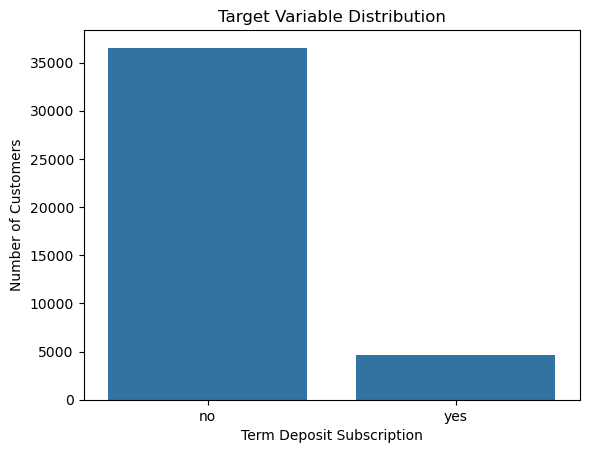

In [9]:
# Target distribution

sns.countplot(data=df,x="y")

plt.title("Target Variable Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Customers")

plt.show()

### EDA Finding – Class Imbalance

The target variable is imbalanced because the number of customers who did not subscribe is much larger than the number who subscribed.

This is important because a model can obtain high accuracy by mainly predicting the majority class while performing poorly on actual buyers. Therefore, Precision, Recall, F1-score and ROC-AUC are also used for evaluation.

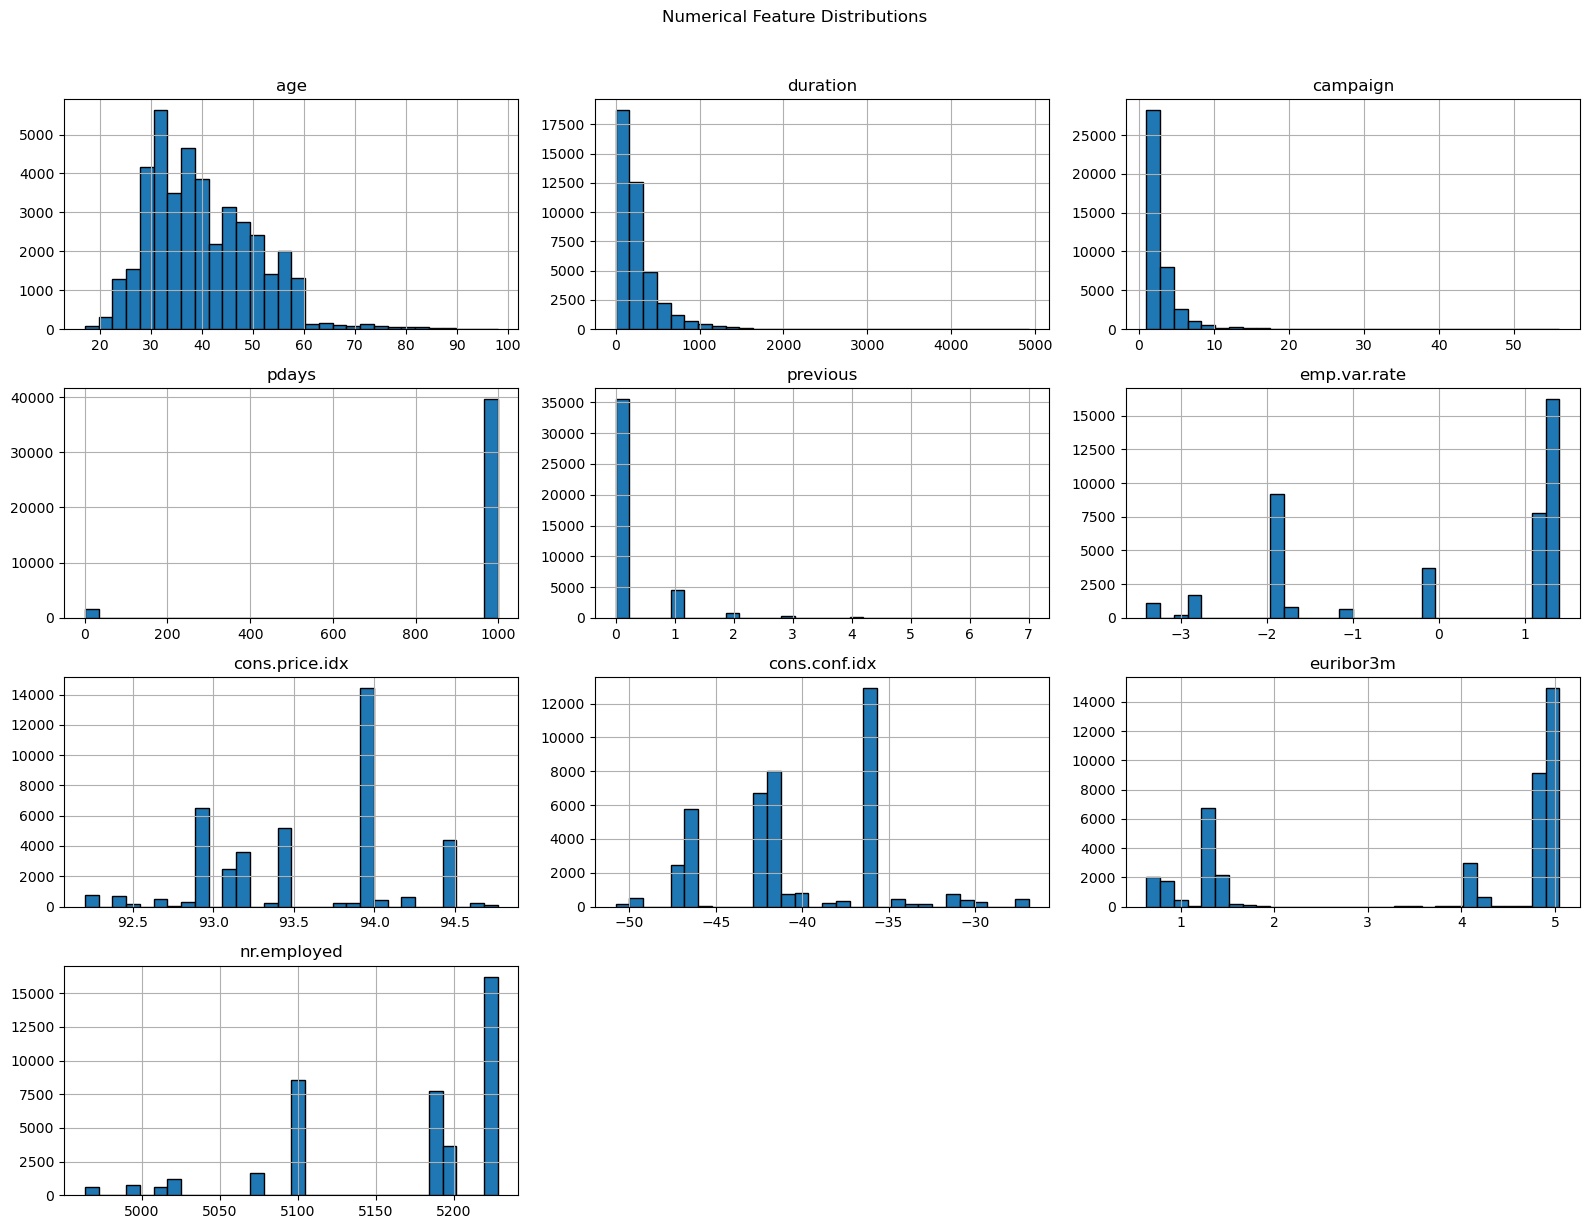

In [10]:
# Numerical feature distributions

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].hist(figsize=(16, 12),bins=30,edgecolor="black")

plt.suptitle("Numerical Feature Distributions",y=1.02)
plt.tight_layout()
plt.show()

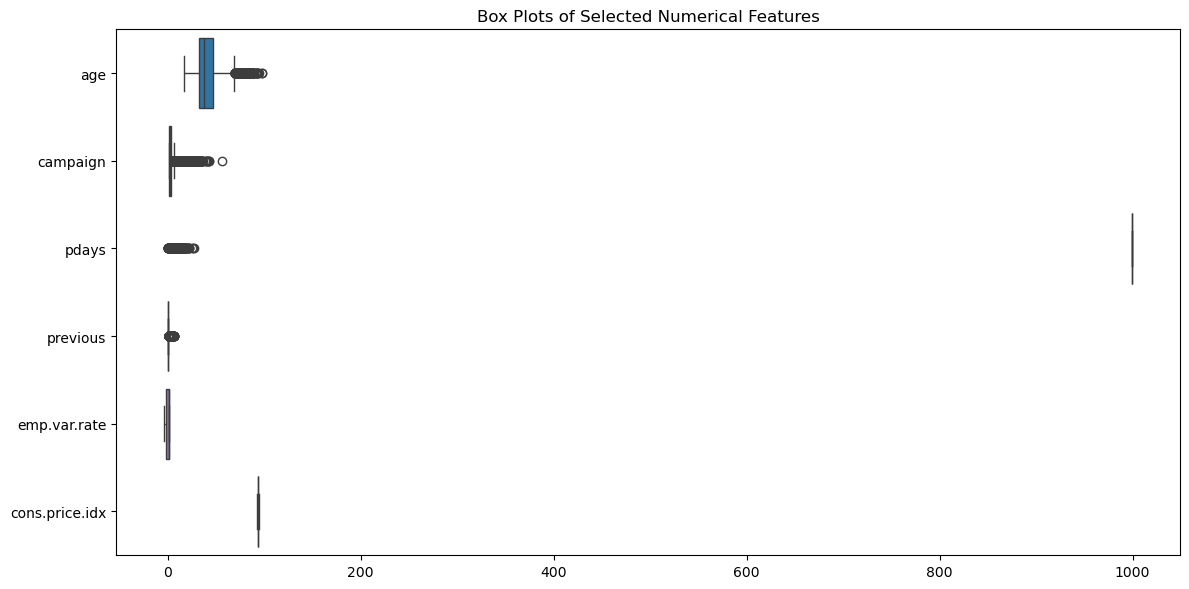

In [11]:
# Box plots for selected numerical features
# Used to inspect distribution and spread

selected_numeric = [
    col for col in [
        "age",
        "campaign",
        "pdays",
        "previous",
        "emp.var.rate",
        "cons.price.idx"
    ]
    if col in df.columns
]

plt.figure(figsize=(12,6))

sns.boxplot(data=df[selected_numeric],orient="h")

plt.title("Box Plots of Selected Numerical Features")

plt.tight_layout()
plt.show()

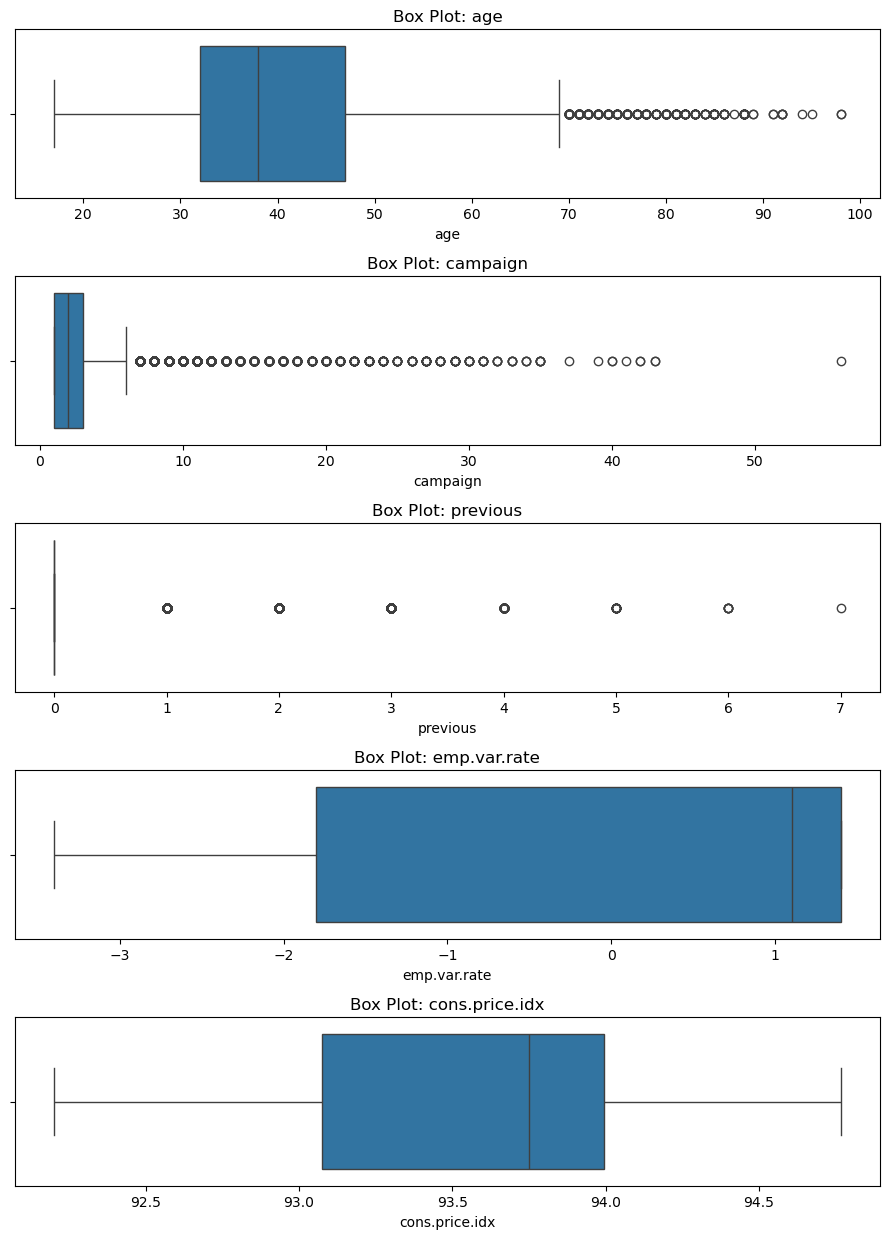

In [12]:
# Box plots for selected numeric features (EDA)
# These plots help inspect spread and possible extreme values.
# No outliers are removed automatically.

box_cols = [
    col for col in [
        "age",
        "campaign",
        "previous",
        "emp.var.rate",
        "cons.price.idx"
    ]
    if col in df.columns
]

fig, axes = plt.subplots(len(box_cols),1,figsize=(9, 2.5 * len(box_cols)))

if len(box_cols) == 1:axes = [axes]

for ax, col in zip(axes, box_cols):

    sns.boxplot(data=df,x=col,ax=ax)

    ax.set_title(f"Box Plot: {col}")

plt.tight_layout()
plt.show()

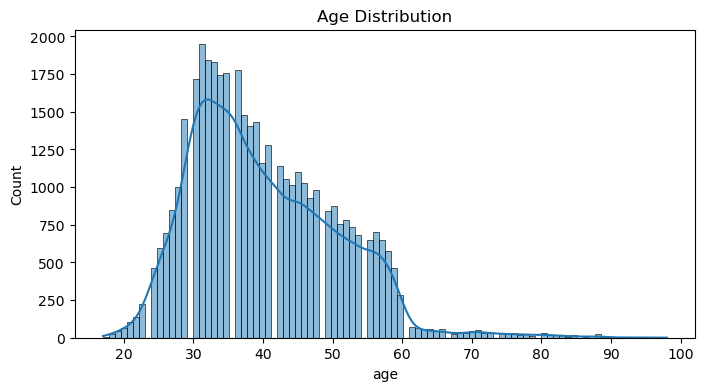

In [13]:
# Age distribution

plt.figure(figsize=(8, 4))

sns.histplot(data=df, x="age",kde=True)

plt.title("Age Distribution")

plt.show()

### Subscription Rate by Job

To understand which customer job categories have a higher likelihood of subscribing to a term deposit, the subscription rate is calculated for each job category.

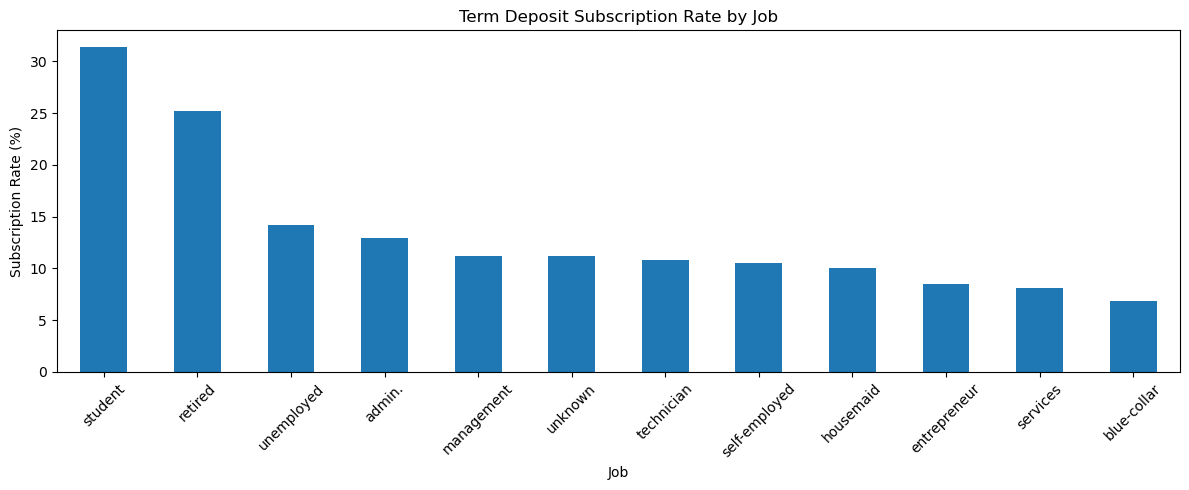

In [14]:
job_subscription_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 5))

job_subscription_rate.plot(kind="bar")

plt.ylabel("Subscription Rate (%)")
plt.xlabel("Job")
plt.title("Term Deposit Subscription Rate by Job")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

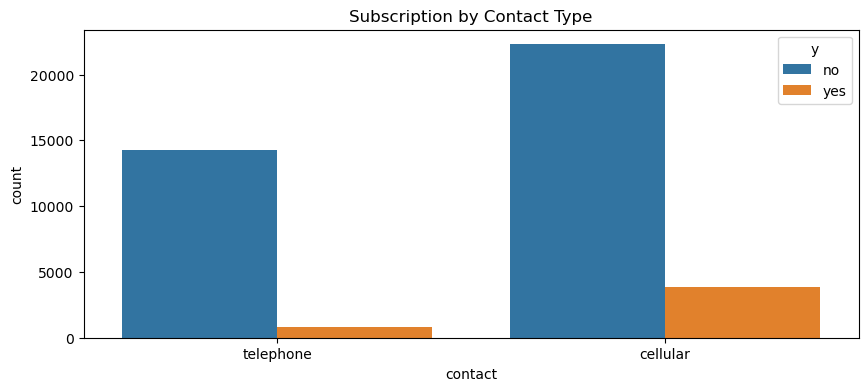

In [15]:
# Campaign contact outcome

plt.figure(figsize=(10, 4))

sns.countplot( data=df,x="contact",hue="y")

plt.title( "Subscription by Contact Type")
plt.show()

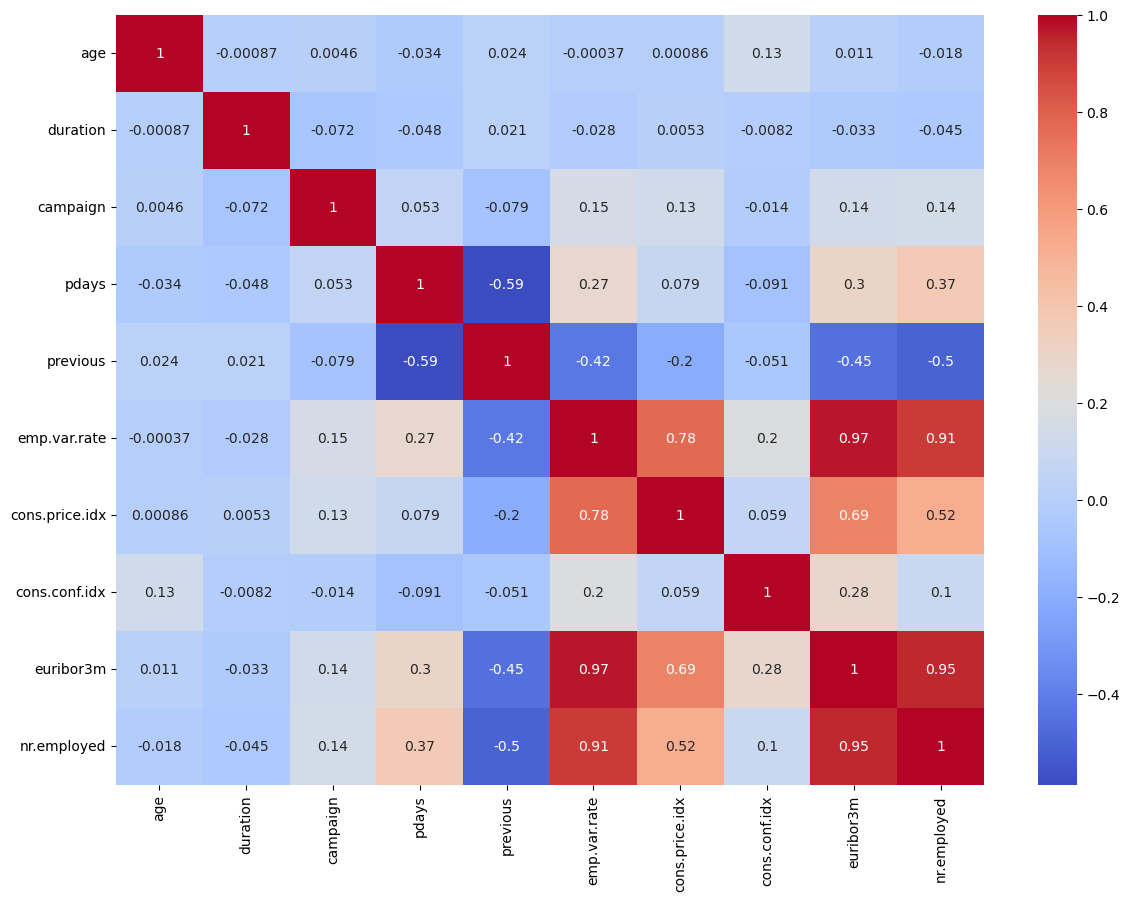

In [16]:
#  Correlation heatmap for numerical variables
plt.figure(figsize=(14, 10))
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True, cmap='coolwarm')
plt.show()

In [17]:
# Numeric correlation with the target

df_corr = df.copy()
df_corr["y_numeric"] = df_corr["y"].map({"no": 0, "yes": 1})

target_corr = (
    df_corr.select_dtypes(include="number")
    .corr()["y_numeric"]
    .drop("y_numeric")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Correlation of numerical features with target:")
display(target_corr.to_frame("Correlation with y"))


Correlation of numerical features with target:


,Correlation with y
duration,0.405274
nr.employed,-0.354678
pdays,-0.324914
euribor3m,-0.307771
emp.var.rate,-0.298334
previous,0.230181
cons.price.idx,-0.136211
campaign,-0.066357
cons.conf.idx,0.054878
age,0.030399


### Multicollinearity and Distribution Checks

The numerical correlation heatmap is used as an initial check for strongly correlated numeric variables. High pairwise correlation can indicate possible multicollinearity, but this heatmap alone does not prove it; a formal follow-up could use Variance Inflation Factor (VIF). The notebook does not remove features based on this check, so no claim is made that multicollinearity has been fully eliminated.

Histograms and box plots are used to inspect feature distributions and spread. A normality test is not required before applying `StandardScaler`: standardization centers and scales features but does not make them normally distributed. Scaling is most relevant to Logistic Regression here; tree-based models generally do not require it.

In [18]:
# Check 'unknown' category values

unknown_summary = {}

for col in df.select_dtypes(include="object").columns:

    count = (df[col] == "unknown").sum()

    if count > 0:

        unknown_summary[col] = { "count": count,"percentage": round(count / len(df) * 100,2)}

unknown_df = pd.DataFrame(unknown_summary).T.sort_values( "count",ascending=False)

unknown_df

,count,percentage
default,8597.0,20.87
education,1731.0,4.20
housing,990.0,2.40
loan,990.0,2.40
job,330.0,0.80
marital,80.0,0.19


### EDA Summary

Key observations:

- The target is imbalanced, so accuracy alone is not sufficient.
- Several variables are categorical and require encoding.
- Some categorical columns contain the value `unknown`. These are retained rather than automatically treated as missing because `unknown` can itself carry information and the dataset does not provide a reliable rule for replacing those values.
- Customer and campaign characteristics show different subscription rates.
- The current-contact `duration` feature is excluded later to avoid leakage in a realistic pre-call prediction setting.

## 5. Data Preprocessing

**Additional checks:** Numeric distributions are visualized with histograms and selected box plots. Normality is not a prerequisite for StandardScaler or for the tree-based models used here; scaling standardizes feature scale but does not make data normally distributed. A correlation heatmap is included as a screening check for strong pairwise relationships among numeric variables. A full multicollinearity assessment (for example, VIF on an appropriately prepared feature matrix) is not performed in this notebook, so multicollinearity is not claimed to have been ruled out.

### Preprocessing decisions

- Exact duplicate rows are removed and categorical columns are one-hot encoded.
- The target is separated before model training; `duration` is excluded because it would not be available for a true pre-call prediction.
- Numerical correlation is reviewed in EDA as an initial multicollinearity check. Normality is not assumed or required for standardization.
- `StandardScaler` is fit on training data only inside the Logistic Regression pipeline; the tree-based models use unscaled features.

In [19]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (41176, 21)


In [20]:
# Separate features and target
# duration is removed because it causes target leakage

X = df.drop(columns=["y", "duration"])
y = df["y"].map({"no": 0, "yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (41176, 19)
y shape: (41176,)


In [21]:
# Convert categorical variables into numerical variables

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Encoded feature count:", X.shape[1])
X.head()

Encoded feature count: 52


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,1,0,0,0,1,0
1,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,1,0,0,0,1,0
2,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,1,0,0,0,1,0
3,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,1,0,0,0,1,0
4,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,...,1,0,0,0,1,0,0,0,1,0


In [22]:
# Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (32940, 52)
Testing data: (8236, 52)


## 6. Handling Class Imbalance

The target variable is imbalanced because the number of customers who did not subscribe is much higher than those who subscribed.

Random undersampling is applied only to the training data. The test data is kept unchanged so that model performance is evaluated on the original customer distribution.

In [23]:
# Check class distribution before balancing
print("Class distribution before balancing:")
print(y_train.value_counts())
print((y_train.value_counts(normalize=True) * 100).round(2))

# Apply undersampling only to the training data
rus = RandomUnderSampler(random_state=42)
X_train_balanced, y_train_balanced = rus.fit_resample(X_train, y_train)

print("\nClass distribution after Random Undersampling:")
print(y_train_balanced.value_counts())
print((y_train_balanced.value_counts(normalize=True) * 100).round(2))


Class distribution before balancing:
y
0    29229
1     3711
Name: count, dtype: int64
y
0    88.73
1    11.27
Name: proportion, dtype: float64

Class distribution after Random Undersampling:
y
0    3711
1    3711
Name: count, dtype: int64
y
0    50.0
1    50.0
Name: proportion, dtype: float64


### Why Random Undersampling?

Random undersampling was selected because the dataset is large and it reduces the majority class quickly.

Advantages:
- Simple and computationally efficient.
- Reduces majority-class dominance.
- Useful for large datasets.

Limitation:
- Some majority-class observations are discarded.

Other possible approaches include `class_weight="balanced"` and SMOTE. These can be tested as future improvements.

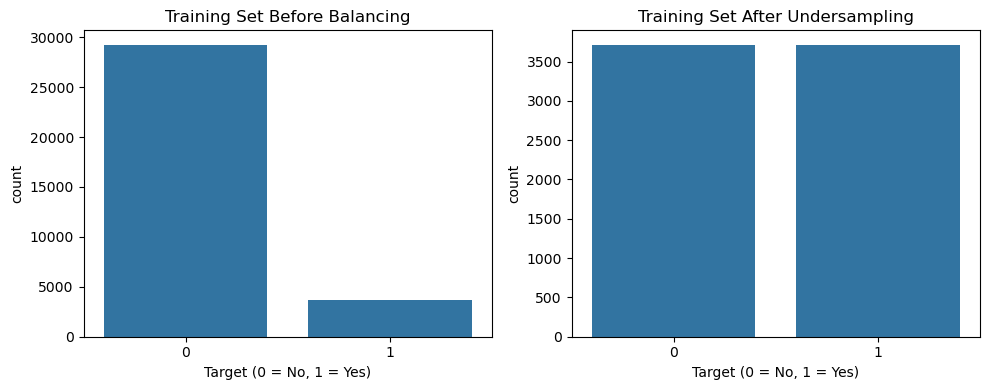

In [24]:
# Visualize class distribution before and after balancing

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Training Set Before Balancing")
axes[0].set_xlabel("Target (0 = No, 1 = Yes)")

sns.countplot(x=y_train_balanced, ax=axes[1])
axes[1].set_title("Training Set After Undersampling")
axes[1].set_xlabel("Target (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

### Evaluation function

In [25]:
def evaluate_model(model_name, model, Xtr, ytr, Xte, yte):
    
    model.fit(Xtr, ytr)
    
    predictions = model.predict(Xte)
    probabilities = model.predict_proba(Xte)[:, 1]
    
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(yte, predictions),
        "Precision": precision_score(yte, predictions, zero_division=0),
        "Recall": recall_score(yte, predictions, zero_division=0),
        "F1 Score": f1_score(yte, predictions, zero_division=0),
        "ROC AUC": roc_auc_score(yte, probabilities)
    }
    
    print("=" * 60)
    print(model_name)
    print("=" * 60)
    
    print(classification_report(
        yte,
        predictions,
        target_names=["No", "Yes"],
        zero_division=0
    ))
    
    print("ROC-AUC:", round(metrics["ROC AUC"], 4))
    
    return model, predictions, probabilities, metrics

## 7. Model Building

The following models are trained on the balanced training data and evaluated on the untouched test data. SVM and Logistic Regression use scaling through pipelines; tree-based models do not require scaling.


### Model 1: Logistic Regression

In [26]:
model_1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model_1, pred_1, prob_1, result_1 = evaluate_model(
    "Logistic Regression",
    model_1,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

Logistic Regression
              precision    recall  f1-score   support

          No       0.95      0.85      0.90      7308
         Yes       0.35      0.65      0.46       928

    accuracy                           0.83      8236
   macro avg       0.65      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236

ROC-AUC: 0.7984


### Model 2: Decision Tree

In [27]:
model_2 = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

model_2, pred_2, prob_2, result_2 = evaluate_model(
    "Decision Tree",
    model_2,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

Decision Tree
              precision    recall  f1-score   support

          No       0.95      0.85      0.90      7308
         Yes       0.35      0.64      0.45       928

    accuracy                           0.82      8236
   macro avg       0.65      0.75      0.67      8236
weighted avg       0.88      0.82      0.85      8236

ROC-AUC: 0.7792


### Model 3: Random Forest

In [28]:
model_3 = RandomForestClassifier(n_estimators=100,max_depth=12,random_state=42,n_jobs=-1)

model_3, pred_3, prob_3, result_3 = evaluate_model(
    "Random Forest",
    model_3,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

Random Forest
              precision    recall  f1-score   support

          No       0.95      0.88      0.91      7308
         Yes       0.40      0.65      0.49       928

    accuracy                           0.85      8236
   macro avg       0.67      0.76      0.70      8236
weighted avg       0.89      0.85      0.86      8236

ROC-AUC: 0.809


### Model 4: Gradient Boosting

In [29]:
model_4 = GradientBoostingClassifier( n_estimators=100,learning_rate=0.1, max_depth=3,random_state=42)

model_4, pred_4, prob_4, result_4 = evaluate_model(
    "Gradient Boosting",
    model_4,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

Gradient Boosting
              precision    recall  f1-score   support

          No       0.95      0.86      0.90      7308
         Yes       0.37      0.66      0.48       928

    accuracy                           0.84      8236
   macro avg       0.66      0.76      0.69      8236
weighted avg       0.89      0.84      0.86      8236

ROC-AUC: 0.8074


### Model 5: XGBoost


In [30]:
model_5 = XGBClassifier(n_estimators=100,learning_rate=0.1, max_depth=4,eval_metric="logloss",random_state=42,n_jobs=-1)

model_5, pred_5, prob_5, result_5 = evaluate_model(
    "XGBoost",
    model_5,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

XGBoost
              precision    recall  f1-score   support

          No       0.95      0.87      0.91      7308
         Yes       0.39      0.66      0.49       928

    accuracy                           0.84      8236
   macro avg       0.67      0.76      0.70      8236
weighted avg       0.89      0.84      0.86      8236

ROC-AUC: 0.8082


### Model 6: Support Vector Machine (SVM)

SVM is sensitive to feature scale, so `StandardScaler` is included inside the pipeline. The model is trained on the balanced training data and evaluated on the original test distribution.


In [31]:
model_6 = Pipeline([ ("scaler", StandardScaler()), ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))])

model_6, pred_6, prob_6, result_6 = evaluate_model(
    "Support Vector Machine",
    model_6,
    X_train_balanced,
    y_train_balanced,
    X_test,
    y_test
)

Support Vector Machine
              precision    recall  f1-score   support

          No       0.95      0.87      0.91      7308
         Yes       0.38      0.64      0.48       928

    accuracy                           0.84      8236
   macro avg       0.66      0.75      0.69      8236
weighted avg       0.89      0.84      0.86      8236

ROC-AUC: 0.7835


## 8. Model Comparison Report

All six models are compared using Accuracy, Precision, Recall, F1-score and ROC-AUC. ROC-AUC is emphasized because the target is imbalanced.


In [32]:
models = {
    "Logistic Regression": model_1,
    "Decision Tree": model_2,
    "Random Forest": model_3,
    "Gradient Boosting": model_4,
    "XGBoost": model_5,
    "Support Vector Machine": model_6
}


In [33]:
results_df = pd.DataFrame([result_1, result_2, result_3, result_4, result_5, result_6])
results_df = results_df.sort_values(by="ROC AUC", ascending=False).reset_index(drop=True)
results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.8498,0.3977,0.6476,0.4928,0.8090
1,XGBoost,0.8442,0.3872,0.6562,0.4870,0.8082
2,Gradient Boosting,0.8366,0.3726,0.6584,0.4759,0.8074
3,Logistic Regression,0.8263,0.3521,0.6455,0.4557,0.7984
4,Support Vector Machine,0.8409,0.3787,0.6422,0.4764,0.7835
5,Decision Tree,0.8238,0.3479,0.6444,0.4518,0.7792


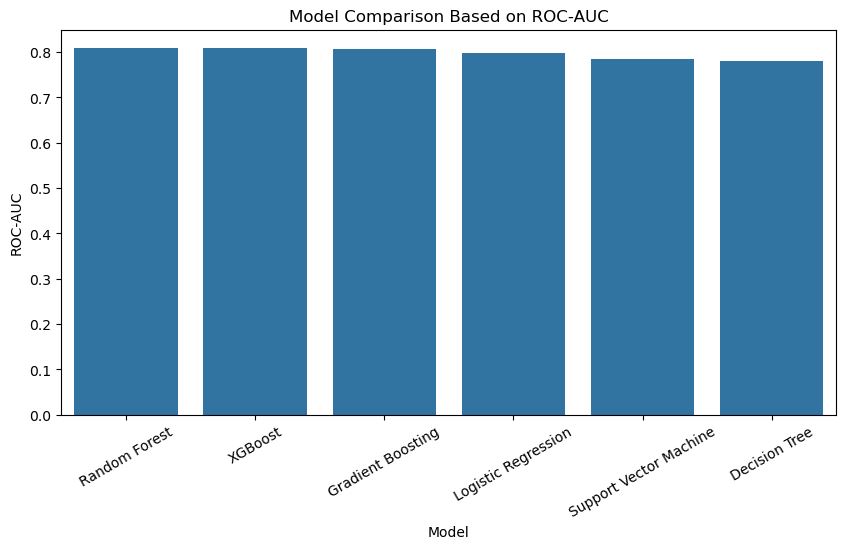

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(data=results_df,x="Model",y="ROC AUC")

plt.xticks(rotation=30)
plt.title("Model Comparison Based on ROC-AUC")
plt.ylabel("ROC-AUC")
plt.show()

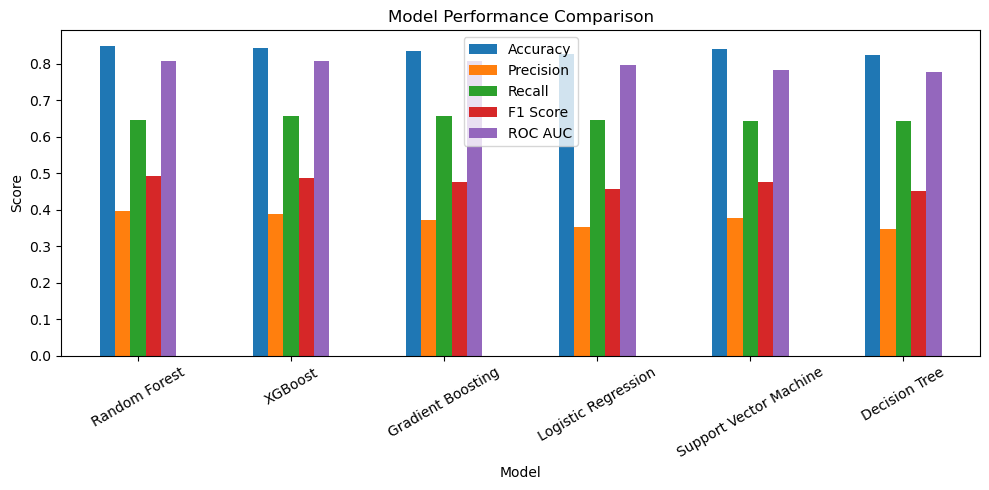

In [35]:
results_df.plot(
    x='Model', y=['Accuracy', 'Precision', 'Recall', 'F1 Score','ROC AUC'],
    kind='bar', figsize=(10, 5)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 9. Best Baseline Model

In [36]:
model_probabilities = {
    "Logistic Regression": prob_1,
    "Decision Tree": prob_2,
    "Random Forest": prob_3,
    "Gradient Boosting": prob_4,
    "XGBoost": prob_5,
    "Support Vector Machine": prob_6
}

In [37]:
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

print("Best model based on ROC-AUC:", best_name)
print("\nBest model results:")

print(
    results_df.iloc[0].to_string()
)

Best model based on ROC-AUC: Random Forest

Best model results:
Model        Random Forest
Accuracy          0.849806
Precision          0.39775
Recall            0.647629
F1 Score          0.492825
ROC AUC           0.809036


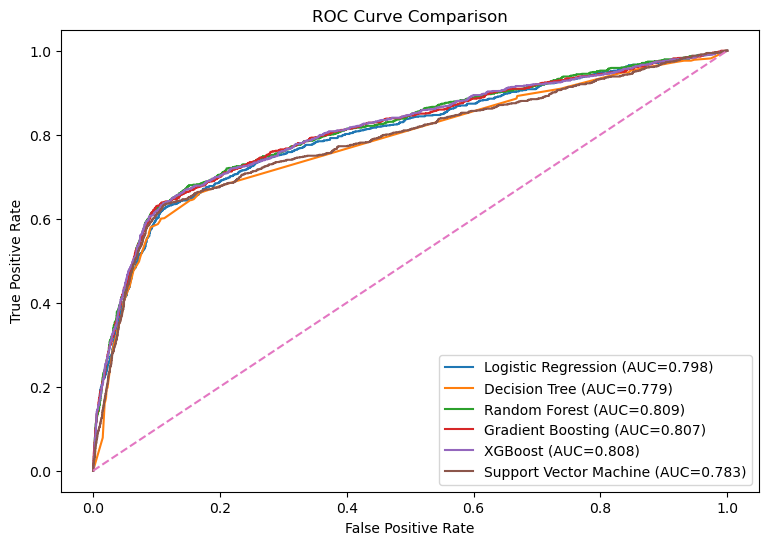

In [38]:
plt.figure(figsize=(9, 6))

for name, probabilities in model_probabilities.items():
    
    fpr, tpr, _ = roc_curve(y_test, probabilities)
    auc_score = roc_auc_score(y_test, probabilities)
    
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc_score:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

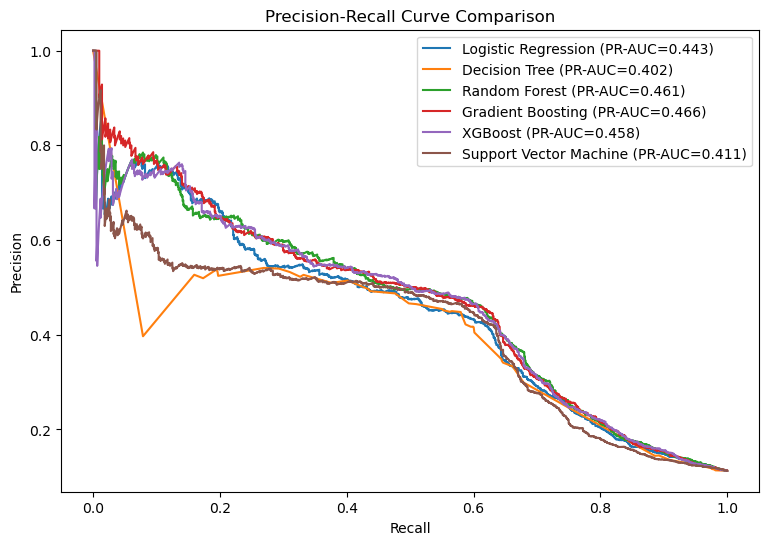

In [39]:
plt.figure(figsize=(9, 6))

for name, probabilities in model_probabilities.items():
    
    precision, recall, _ = precision_recall_curve( y_test, probabilities)
    
    pr_auc = auc(recall, precision)
    
    plt.plot( recall, precision,label=f"{name} (PR-AUC={pr_auc:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.show()

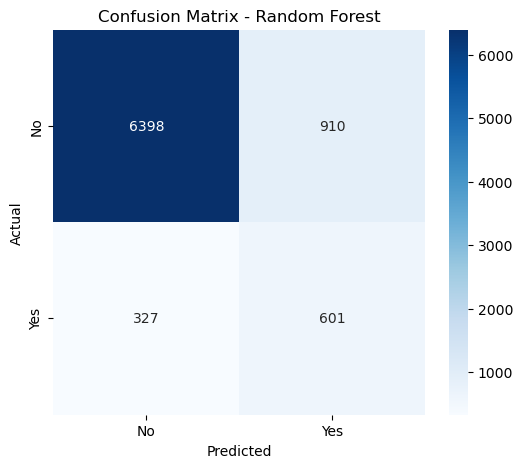

In [40]:
best_prob = model_probabilities[best_name]
best_pred = (best_prob >= 0.50).astype(int)

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues", xticklabels=["No", "Yes"],yticklabels=["No", "Yes"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

## 10. Cross-Validation

A single train-test split provides one estimate of model performance. Stratified 5-fold cross-validation provides a more reliable estimate by evaluating the model across multiple training and validation folds while preserving the class distribution.

For cross-validation, Random Undersampling is performed inside each training fold rather than before cross-validation. This prevents information leakage and ensures that the validation fold remains untouched.

The final test set is not used during cross-validation and is reserved for final evaluation.

In [41]:
from imblearn.pipeline import Pipeline as ImbPipeline

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_pipeline = ImbPipeline([
    ("sampler", RandomUnderSampler(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

cv_scores = cross_val_score(
    cv_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

print("5-Fold ROC-AUC scores:")
print(np.round(cv_scores, 4))

print("\nMean ROC-AUC:",
      round(cv_scores.mean(), 4))

print("Std ROC-AUC:",
      round(cv_scores.std(), 4))

5-Fold ROC-AUC scores:
[0.7991 0.7833 0.7752 0.7978 0.7848]

Mean ROC-AUC: 0.788
Std ROC-AUC: 0.0091


### Cross-Validation Interpretation

Five-fold stratified cross-validation checks whether the Logistic Regression model gives stable ROC-AUC values across different training and validation folds.

## 11.  Hyperparameter Tuning

Hyperparameter tuning can improve the selected tree-based model. The following RandomizedSearchCV example tunes Random Forest.

Randomized search is used instead of a large grid because the dataset is relatively large and exhaustive grid search can take substantially longer.

In [42]:
# Random Forest Hyperparameter Tuning
# Undersampling is performed inside each CV training fold

rf_pipeline = ImbPipeline([("sampler", RandomUnderSampler(random_state=42)),("model", RandomForestClassifier(random_state=42,n_jobs=-1))])

rf_param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(estimator=rf_pipeline,param_distributions=rf_param_dist,n_iter=10,
    scoring="roc_auc",cv=3,random_state=42,n_jobs=-1,verbose=1)

rf_search.fit(X_train, y_train)

print("Best parameters:")
print(rf_search.best_params_)

print("\nBest cross-validation ROC-AUC:",round(rf_search.best_score_, 4))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 12}

Best cross-validation ROC-AUC: 0.7952


In [43]:
# Best tuned Random Forest pipeline

tuned_rf_pipeline = rf_search.best_estimator_

print("Tuned Random Forest created successfully.")

print("\nBest parameters:")
print(rf_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    round(rf_search.best_score_, 4)
)

Tuned Random Forest created successfully.

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 12}

Best cross-validation ROC-AUC: 0.7952


## 12. Threshold Tuning

The default classification threshold is 0.50.

For bank marketing, the threshold can be adjusted depending on business requirements.

- Lower threshold → generally higher recall but lower precision.
- Higher threshold → generally higher precision but lower recall.

The threshold is selected using a validation set, while the final test set is kept untouched for unbiased evaluation.

The threshold producing the highest validation F1-score is selected for the final evaluation.

In [44]:
# Split the training data into training and validation sets

X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train,y_train,test_size=0.20,random_state=42,stratify=y_train)

# Train the tuned Random Forest pipeline on the training portion
tuned_rf_pipeline.fit(X_train_sub, y_train_sub)

# Get validation probabilities
val_prob = tuned_rf_pipeline.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)

threshold_rows = []

for threshold in thresholds:

    val_pred = (
        val_prob >= threshold
    ).astype(int)

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            val_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_val,
            val_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold_row = threshold_df.loc[threshold_df["F1 Score"].idxmax()]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold based on validation F1:")
print(best_threshold_row.round(4))

threshold_df

Best threshold based on validation F1:
Threshold    0.6000
Precision    0.4355
Recall       0.6011
F1 Score     0.5051
Name: 10, dtype: float64


,Threshold,Precision,Recall,F1 Score
0,0.10,0.112663,1.000000,0.202511
1,0.15,0.114118,0.994609,0.204744
2,0.20,0.121096,0.977089,0.215485
3,0.25,0.132211,0.942049,0.231879
4,0.30,0.165117,0.909704,0.279503
5,0.35,0.222808,0.797844,0.348338
6,0.40,0.286952,0.714286,0.409424
7,0.45,0.342818,0.681941,0.456267
8,0.50,0.392013,0.648248,0.488573
9,0.55,0.417195,0.621294,0.499188


In [47]:
# Train final tuned Random Forest on the complete training data

final_rf_pipeline = rf_search.best_estimator_

final_rf_pipeline.fit(
    X_train,
    y_train
)

# Predict probabilities on untouched test data

test_prob = final_rf_pipeline.predict_proba(X_test)[:, 1]

# Apply the threshold selected using validation data

final_test_pred = (
    test_prob >= best_threshold
).astype(int)

print("Final Test Performance")
print("=" * 50)

print("Selected threshold:", round(best_threshold, 2))

print(
    classification_report(
        y_test,
        final_test_pred,
        target_names=["No", "Yes"],
        zero_division=0
    )
)

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, test_prob),
        4
    )
)

print(
    "F1 Score:",
    round(
        f1_score(y_test, final_test_pred),
        4
    )
)

Final Test Performance
Selected threshold: 0.6
              precision    recall  f1-score   support

          No       0.95      0.90      0.93      7308
         Yes       0.45      0.62      0.52       928

    accuracy                           0.87      8236
   macro avg       0.70      0.76      0.72      8236
weighted avg       0.89      0.87      0.88      8236

ROC-AUC: 0.8112
F1 Score: 0.521


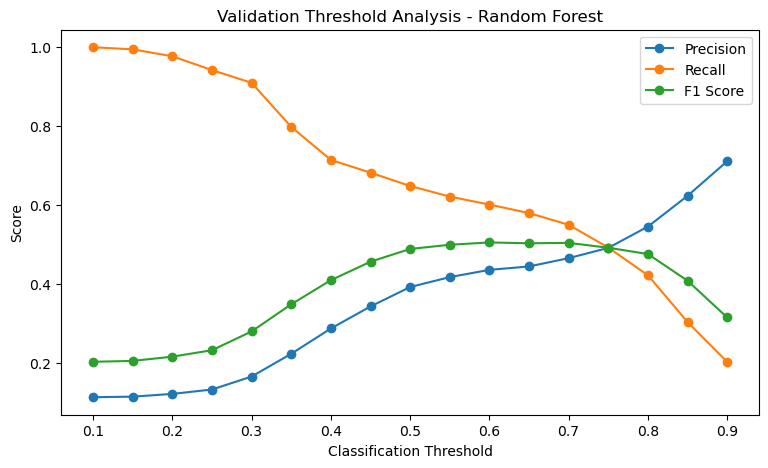

In [48]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(f"Validation Threshold Analysis - {best_name}")
plt.legend()
plt.show()

## 13. Feature Importance / Interpretability

Random Forest provides model-specific feature-importance scores that can help the marketing team understand which encoded variables contribute most to predictions. These scores should not be interpreted as causal effects.

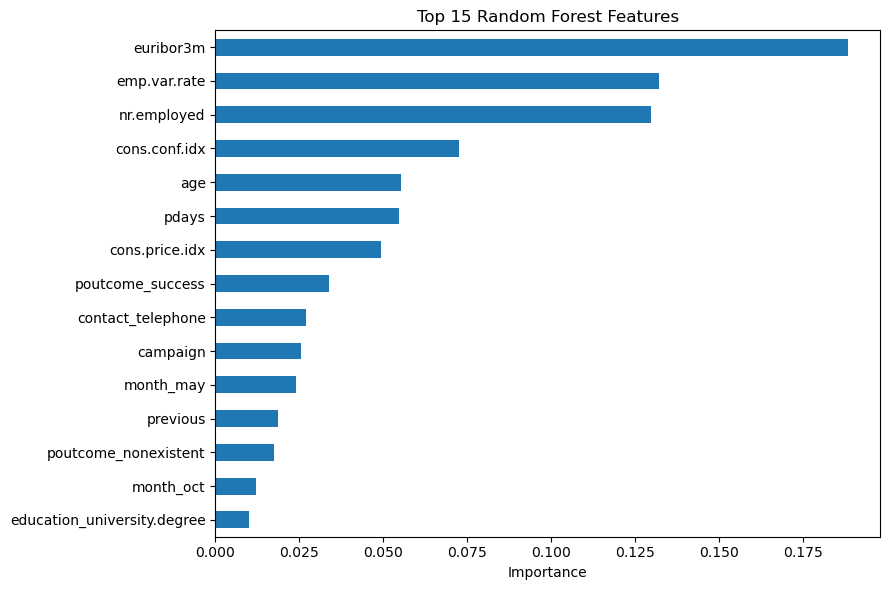

,Importance
euribor3m,0.188649
emp.var.rate,0.132238
nr.employed,0.129916
cons.conf.idx,0.072453
age,0.055396
pdays,0.054777
cons.price.idx,0.049234
poutcome_success,0.033901
contact_telephone,0.026979
campaign,0.025472


In [49]:
# Extract the Random Forest model from the pipeline

final_rf_model = final_rf_pipeline.named_steps["model"]

rf_importance = pd.Series(
    final_rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top_features = rf_importance.head(15)

plt.figure(figsize=(9, 6))

top_features.sort_values().plot(
    kind="barh"
)

plt.xlabel("Importance")
plt.title("Top 15 Random Forest Features")

plt.tight_layout()
plt.show()

display(
    top_features.to_frame("Importance")
)

## 14. Challenges Faced and Techniques Used

### Challenge 1 – Class imbalance
**Problem:** The number of non-subscribers is much larger than subscribers.

**Technique:** Random undersampling was applied only to the training set.

**Reason:** It prevents the majority class from dominating training while keeping the test set in its original distribution.

### Challenge 2 – Categorical variables
**Problem:** Many predictors are categorical and machine-learning algorithms require numerical input.

**Technique:** One-hot encoding using `pd.get_dummies()`.

**Reason:** It converts categories into numerical indicator variables without imposing an artificial numerical order.

### Challenge 3 – Target leakage
**Problem:** `duration` is related to the current marketing call and would not be available when deciding which customer to call.

**Technique:** Removed `duration` before model training.

**Reason:** This makes the model more realistic for pre-call customer targeting.

### Challenge 4 – Missing/unknown category values
**Problem:** Some categorical columns contain `unknown`.

**Technique:** Retained `unknown` as a category.

**Reason:** There is no reliable evidence in the dataset for replacing these values, and `unknown` may contain useful information.

### Challenge 5 – Model evaluation
**Problem:** Accuracy can be misleading with an imbalanced target.

**Technique:** Used Precision, Recall, F1-score, ROC-AUC and confusion matrix in addition to Accuracy.

**Reason:** These metrics provide a better view of the model's ability to identify potential subscribers.

### Challenge 6 – Scaling
**Problem:** Logistic Regression can be affected by different feature scales.

**Technique:** StandardScaler is used inside the Logistic Regression pipeline.

**Reason:** Scaling improves numerical stability and gives features a comparable scale. Tree-based models do not require feature scaling.

### Challenge 7 – Feature scaling for SVM
**Problem:** SVM is sensitive to differences in feature scale.

**Technique:** StandardScaler is included inside the SVM pipeline.

**Reason:** Scaling puts numeric features on a comparable scale and is important for SVM.

### Challenge 8 – Generalization
**Problem:** A single train-test split can give an unstable estimate of performance.

**Technique:** Added stratified 5-fold cross-validation.

**Reason:** It provides a more reliable estimate of model performance across multiple training/validation splits.

### Challenge 9– Hyperparameter selection

**Problem:** Default model parameters may not provide the best performance.

**Technique:** RandomizedSearchCV was used to tune the Random Forest hyperparameters.

**Reason:** RandomizedSearchCV searches multiple parameter combinations efficiently. Random undersampling was included inside the cross-validation pipeline so that balancing was performed only on the training portion of each fold.


## Business Implications

The model can help the bank prioritize customers who are more likely to subscribe to a term deposit.

### False Positive
The model predicts that a customer will subscribe, but the customer does not subscribe.

**Business impact:** The bank may spend unnecessary time and calling resources.

### False Negative
The model predicts that a customer will not subscribe, but the customer would have subscribed.

**Business impact:** The bank may miss a potential customer.

### Practical Decision

If the bank has limited calling staff or high campaign costs, higher precision may be more important.

If missing potential customers is more costly, higher recall may be preferred.

Therefore, the final classification threshold should be selected using campaign cost, expected customer value and validation results rather than ROC-AUC alone.

## 15. Final Model Recommendation

Random Forest achieved the highest ROC-AUC among the baseline models and was therefore selected as the best baseline model.

Hyperparameter tuning was then performed using RandomizedSearchCV to improve the Random Forest model. The tuned model was evaluated on the untouched test set after selecting the classification threshold using the validation set.

The final model achieved a ROC-AUC of 0.8112, with 0.45 precision, 0.62 recall and 0.52 F1-score for the positive class at a threshold of 0.60.

Before deployment, the model should also be validated on later campaign data and evaluated using business-relevant metrics.

The classification threshold should be selected using validation data rather than the final test set. The final threshold should consider campaign cost, expected customer value, precision and recall.

Additional improvements that can be evaluated include:

- Comparing Random Undersampling with class-weighted models.
- Testing SMOTE or other resampling techniques.
- Probability calibration.
- Validation using later time periods.
- Monitoring Precision, Recall, F1-score and ROC-AUC after deployment.
- Monitoring changes in customer and campaign characteristics.
- Retraining the model when performance decreases.
- Checking model fairness and stability.

The final production model should balance predictive performance, business cost, interpretability and stability over time.

## 16. Conclusion

This project completed exploratory data analysis, preprocessing, class-imbalance handling, correlation analysis and comparison of six machine-learning models: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost and Support Vector Machine (SVM).

The target imbalance was handled using Random Undersampling on the training data only, while the test set retained its original distribution. The `duration` feature was excluded because it would cause target leakage in a realistic pre-call prediction scenario.

Model performance was evaluated using Accuracy, Precision, Recall, F1-score and ROC-AUC. Random Forest achieved the highest ROC-AUC among the baseline models and was selected as the best baseline model. Hyperparameter tuning was then applied to Random Forest.

Cross-validation was performed using undersampling within the training folds to reduce the risk of data leakage. Classification threshold tuning was performed using validation data, while the final test set was reserved for unbiased evaluation.

For deployment, the model should be validated on later campaign data and monitored using business-relevant metrics. The final threshold should consider campaign costs, customer value, precision and recall rather than relying on ROC-AUC alone.

Overall, the project demonstrates a complete machine-learning workflow from business understanding and EDA to preprocessing, class-imbalance handling, model comparison, cross-validation, hyperparameter tuning, threshold selection and business interpretation.
